In [2]:
import torch
import torch.nn as nn
import kagglehub
import os
from pathlib import Path
import shutil
from torchvision import datasets
from torch.utils.data import Subset, DataLoader, Dataset, random_split
import random
from torchvision.transforms import v2
import torch.optim as optim
from typing import Tuple, Dict, List
from tqdm import tqdm
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import copy
import torch.optim.lr_scheduler as lr_scheduler



device = "cuda" if torch.cuda.is_available() else "cpu"

def process(device: torch.device,
            data_root: str = "data/",
            dataset_name: str = "miljan/stanford-dogs-dataset-traintest",
            num_classes: int = 5,
            batch_size: int = 32,
            seed: int = 42,
            num_workers: int = 2,
            layer_1: int =32,
            layer_2: int =64,
            layer_3: int =128,
            learning_rate: float = 0.0005,
            loss_fn: torch.nn = nn.CrossEntropyLoss(),
            epochs: int = 10,
            early_stopping_patience: int = 15,
            scheduling_patience: int = 3,
            weight_decay: float = 0.0001,
            step_size: int = 8,
            factor: float = 0.5,
            val_split: float = 0.1
            ):
    
    class RemapSubset(Dataset):
        """Wraps a Subset and remaps labels to contiguous [0..num_classes-1]."""
        def __init__(self, subset, selected_indices):
            self.subset = subset
            self.label_map = {old: new for new, old in enumerate(selected_indices)}
    
        def __len__(self):
            return len(self.subset)
    
        def __getitem__(self, idx):
            x, y = self.subset[idx]
            return x, self.label_map[y]

    def load_kaggle(data_root: str = "data/",
                    dataset_name: str = "miljan/stanford-dogs-dataset-traintest",
                    num_classes: int = None,
                    batch_size: int = 32,
                    seed: int = 42,
                    num_workers: int = 2):
        """
        Download, prepare and optionally subset the Stanford Dogs dataset.
        Labels are remapped to contiguous indices when subsetting.
    
        Args:
            data_root (str): Root folder to store data.
            dataset_name (str): Kaggle dataset identifier.
            num_classes (int): If provided, randomly subset to this many classes.
            batch_size (int): Batch size for dataloaders.
            seed (int): Random seed for reproducibility.
    
        Returns:
            train_dataloader, test_dataloader, class_names
        """
        data_path = Path(data_root)
        image_path = data_path / "dog_breeds"
    
        # Download if not already present
        if not image_path.is_dir():
            print(f"{image_path} directory doesn't exist ... downloading dataset")
            image_path.mkdir(parents=True, exist_ok=True)
            original_path = kagglehub.dataset_download(dataset_name)
            shutil.copytree(original_path, image_path, dirs_exist_ok=True)
        else:
            print(f"{image_path} directory exists already ... skipping download")
    
        # Define train/test dirs
        train_dir = image_path / "cropped/cropped/train"
        test_dir = image_path / "cropped/cropped/test"
    
        # Define transforms
        transforms = v2.Compose([
            v2.ToImage(),
            v2.Resize(size=(224, 224), antialias=True),
            v2.ToDtype(torch.float32, scale=True),  # scales to [0,1]
        ])
        train_transforms = v2.Compose([
            v2.ToImage(),
            v2.Resize((224,224), antialias=True),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(10),
            v2.ColorJitter(brightness=0.2, contrast=0.2),
            v2.ToDtype(torch.float32, scale=True),
        ])

    
        # Load datasets
        full_train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
        test_data = datasets.ImageFolder(root=test_dir, transform=transforms)
    
        if num_classes is not None:
            random.seed(seed)
            selected_classes = random.sample(full_train_data.classes, num_classes)
            class_to_idx = full_train_data.class_to_idx
            selected_indices = [class_to_idx[c] for c in selected_classes]
    
            train_subset_indices = [i for i, (_, label) in enumerate(full_train_data.samples) if label in selected_indices]
            test_subset_indices = [i for i, (_, label) in enumerate(test_data.samples) if label in selected_indices]
    
            full_train_data = RemapSubset(Subset(full_train_data, train_subset_indices), selected_indices)
            test_data = RemapSubset(Subset(test_data, test_subset_indices), selected_indices)
    
            class_names = [c.split("-", 1)[1] for c in selected_classes]
            if num_classes <= 5:
                print(f"Selected Classes: {class_names}")
            else:
                pass
        else:
            class_names = [c.split("-", 1)[1] for c in full_train_data.classes]
    
        # Split train into train + validation
        val_size = int(len(full_train_data) * val_split)
        train_size = len(full_train_data) - val_size
        train_data, val_data = random_split(full_train_data, [train_size, val_size],
                                            generator=torch.Generator().manual_seed(seed))



        # Create dataloaders
        train_dataloader = DataLoader(train_data,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=0,   
                                  pin_memory=False)
    
        test_dataloader = DataLoader(test_data,
                                     batch_size=batch_size,
                                     shuffle=False,
                                     num_workers=0,
                                     pin_memory=False)
        val_dataloader = DataLoader(val_data,
                                     batch_size=batch_size,
                                     shuffle=False,
                                     num_workers=0,
                                     pin_memory=False)
    
        return train_dataloader, test_dataloader, val_dataloader, class_names

    train_dataloader, test_dataloader, val_dataloader, class_names = load_kaggle(num_classes=num_classes)

    class DogBreedClassifier(nn.Module):
        def __init__(self,
                     in_size: int,
                     layer_1: int,
                     layer_2: int,
                     layer_3: int,
                     out_size: int):
            super().__init__()
            
            # Convolutional blocks with BatchNorm + padding
            self.conv_block_1 = nn.Sequential(
                nn.Conv2d(in_channels=in_size, out_channels=layer_1, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_1),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_1, out_channels=layer_1, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            self.conv_block_2 = nn.Sequential(
                nn.Conv2d(in_channels=layer_1, out_channels=layer_2, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_2),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_2, out_channels=layer_2, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_2),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            self.conv_block_3 = nn.Sequential(
                nn.Conv2d(in_channels=layer_2, out_channels=layer_3, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_3),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_3, out_channels=layer_3, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_3),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            # Global Average Pooling instead of flatten
            self.gap = nn.AdaptiveAvgPool2d((1,1))
            
            # Classifier with hidden dense layer
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(p=0.5),
                nn.Linear(layer_3, 2*layer_3),
                nn.ReLU(),
                nn.Dropout(p=0.5),
                nn.Linear(2*layer_3, out_size)
            )
            
        def forward(self, x):
            x = self.conv_block_1(x)
            x = self.conv_block_2(x)
            x = self.conv_block_3(x)
            x = self.gap(x)
            return self.classifier(x)

    model = DogBreedClassifier(in_size=3,
                               layer_1=layer_1,
                               layer_2=layer_2,
                               layer_3=layer_3,
                               out_size = len(class_names))
    
    optimizer = optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=factor, patience=scheduling_patience)
    
    def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device) -> Tuple[float, float]:
        model.to(device)
        model.train()
        train_loss, train_acc = 0,0
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device) 
            logit = model(X)
            loss = loss_fn(logit, y)
            train_loss += loss.item()
            pred = torch.softmax(logit, dim=1).argmax(dim=1)
            train_acc += (pred==y).sum().item()/len(logit)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss /= len(dataloader)
        train_acc /= len(dataloader)
        return train_loss, train_acc

    def eval_step(model,
                  dataloader,
                  loss_fn,
                  device) -> Tuple[float, float]:
        """
        Evaluate the model on a given dataloader (validation or test).
        Returns average loss and accuracy.
        """
        model.to(device)
        model.eval()
        total_loss, total_acc = 0.0, 0.0
    
        with torch.inference_mode():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                loss = loss_fn(logits, y)
                total_loss += loss.item()
    
                preds = torch.softmax(logits, dim=1).argmax(dim=1)
                total_acc += (preds == y).sum().item() / len(y)
    
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        return avg_loss, avg_acc


    def plot_results(results):
        epochs = range(1, len(results["train_loss"]) + 1)
        plt.figure(figsize=(10,4))
    
        # Loss curves
        plt.subplot(1,2,1)
        plt.plot(epochs, results["train_loss"], label="Train Loss")
        plt.plot(epochs, results["val_loss"], label="Val Loss")
        plt.legend(); plt.title("Loss")
    
        # Accuracy curves
        plt.subplot(1,2,2)
        plt.plot(epochs, results["train_acc"], label="Train Acc")
        plt.plot(epochs, results["val_acc"], label="Val Acc")
        plt.legend(); plt.title("Accuracy")
    
        plt.show()
    
        # Print final test metrics
        if len(results["test_loss"]) > 0:
            print(f"Final Test Loss: {results['test_loss'][-1]:.4f}, "
                  f"Test Acc: {results['test_acc'][-1]:.2f}%")




    class EarlyStopping:
        def __init__(self, patience=early_stopping_patience, min_delta=0.0):
            """
            Args:
                patience (int): How many epochs to wait after last improvement.
                min_delta (float): Minimum change to qualify as improvement.
            """
            self.patience = patience
            self.min_delta = min_delta
            self.best_loss = None
            self.counter = 0
            self.should_stop = False
    
        def step(self, val_loss):
            if self.best_loss is None:
                self.best_loss = val_loss
                return
    
            if val_loss < self.best_loss - self.min_delta:
                self.best_loss = val_loss
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.should_stop = True

    def train(model = model,
          train_dataloader = train_dataloader,
          test_dataloader = test_dataloader,
          loss_fn = loss_fn,
          optimizer = optimizer,
          scheduler = scheduler,
          epochs = epochs,
          device = device,
          early_stopping_patience = early_stopping_patience) -> Dict[str, List[float]]:
        """
        Trains and tests a Convolutional Neural Network.
        Passes a target PyTorch models through train_step() and test_step()
        functions for a number of epochs, training and testing the model
        in the same epoch loop.
        
        Calculates, prints and stores evaluation metrics throughout.
    
        Args:
        model: A PyTorch model to be trained and tested.
        train_dataloader: A DataLoader instance for the model to be trained on.
        test_dataloader: A DataLoader instance for the model to be tested on.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        loss_fn: A PyTorch loss function to calculate loss on both datasets.
        epochs: An integer indicating how many epochs to train for.
        device: A target device to compute on (e.g. "cuda" or "cpu").
        scheduler ...
        early_stopping_patience ...
    
        Returns:
        A dictionary of training and testing loss as well as training and
        testing accuracy metrics. Each metric has a value in a list for
        each epoch.
        model ...
        In the form: {train_loss: [...],
                      train_acc: [...],
                      test_loss: [...],
                      test_acc: [...]}
        """
        start_time = timer()
        # Create empty results dictionary
        results = {"train_loss": [],
                   "train_acc": [],
                   "val_loss": [],
                   "val_acc": [],
                   "test_loss": [],
                   "test_acc": []}
        early_stopping = EarlyStopping(patience=early_stopping_patience)
        best_model_wts = copy.deepcopy(model.state_dict())


        
        for epoch in tqdm(range(epochs), desc="Epochs"):
            # Training step
            train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    
            # Validation step
            val_loss, val_acc = eval_step(model, val_dataloader, loss_fn, device)
    
            # Scheduler reacts to validation loss
            scheduler.step(val_loss)
    
            # Early stopping check
            if early_stopping.best_loss is None or val_loss < early_stopping.best_loss - early_stopping.min_delta:
                best_model_wts = copy.deepcopy(model.state_dict())
            early_stopping.step(val_loss)
    
            if early_stopping.should_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(best_model_wts)
                break
    
            # Print progress
            print_train_acc = train_acc * 100
            print_val_acc = val_acc * 100
            if epoch == 0 or (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {print_train_acc:.2f}% "
                      f"| val_loss: {val_loss:.4f} | val_acc: {print_val_acc:.2f}% "
                      f"| LR: {optimizer.param_groups[0]['lr']:.6f}")
    
            # Save results
            results["train_loss"].append(train_loss)
            results["train_acc"].append(print_train_acc)
            results["val_loss"].append(val_loss)
            results["val_acc"].append(print_val_acc)
    
        # Final test evaluation
        test_loss, test_acc = eval_step(model, test_dataloader, loss_fn, device)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc * 100)
    
        end_time = timer()
        print(f"Training finished in {end_time-start_time:.2f} seconds")
        print(f"Final test loss: {test_loss:.4f}, test acc: {test_acc*100:.2f}%")
    
        plot_results(results)
        return model, results
  
    model, results  = train()
    return model, results, class_names
    

data\dog_breeds directory exists already ... skipping download


Epochs:   1%|▌                                                                                         | 1/150 [00:54<2:14:48, 54.29s/it]

Epoch 1 | train_loss: 4.7530 | train_acc: 1.13% | val_loss: 4.6099 | val_acc: 2.88% | LR: 0.000500


Epochs:   7%|█████▉                                                                                   | 10/150 [07:07<1:37:07, 41.62s/it]

Epoch 10 | train_loss: 4.0554 | train_acc: 6.54% | val_loss: 3.9909 | val_acc: 6.17% | LR: 0.000500


...

Epochs:  73%|████████████████████████████████████████████████████████████████▌                       | 110/150 [1:16:29<27:43, 41.59s/it]

Epoch 110 | train_loss: 2.8427 | train_acc: 23.68% | val_loss: 2.7390 | val_acc: 25.99% | LR: 0.000000


Epochs:  78%|████████████████████████████████████████████████████████████████████▋                   | 117/150 [1:22:01<23:08, 42.07s/it]

Early stopping triggered at epoch 118


Training finished in 4941.69 seconds
Final test loss: 2.6080, test acc: 30.94%


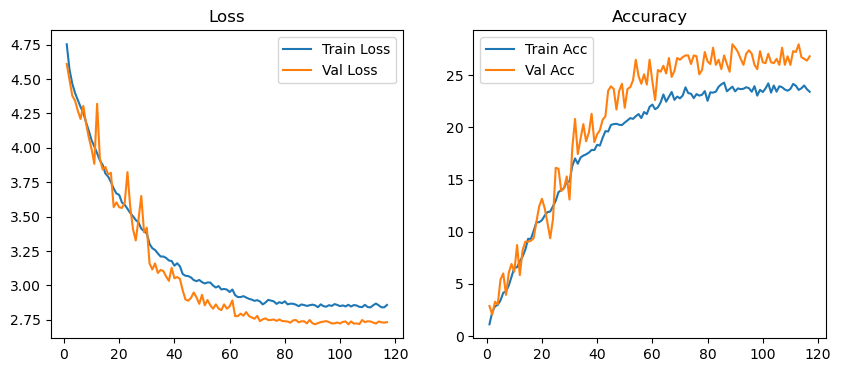

Final Test Loss: 2.6080, Test Acc: 30.94%


In [3]:
model, model_results, class_names = process(device="cuda", epochs=150, num_classes=120)

In [4]:
import torch
from pathlib import Path

# Create a models directory if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the entire model (architecture + weights)
torch.save(model.state_dict(), models_dir / "dog_breed_classifier_original.pth")

In [5]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from PIL import Image
import numpy as np

def pred_images(model: torch.nn.Module, 
                image_path: str, 
                class_names: list, 
                device: torch.device,
                image_extensions: list[str] = [".jpg", ".jpeg", ".png"]):
    """
    Generate predictions for a batch of images and visualize results in a grid.

    This function loads all valid image files from a given directory, applies a
    preprocessing pipeline, performs inference with a trained model, and plots
    the images alongside their predicted labels and probabilities using Matplotlib
    subplots. The breed name is displayed in bold, and the probability is shown
    in smaller text within the title.

    Parameters
    ----------
    model : torch.nn.Module
        The trained PyTorch model used for inference.
    image_path : str
        Path to the directory containing input images.
    class_names : list
        List of class names corresponding to model output indices.
    device : torch.device
        Device on which to run inference (e.g., "cpu" or "cuda").

    Returns
    -------
    predictions : list of int
        Predicted class indices for each image.
    prediction_labels : list of str
        Predicted class names for each image.
    probabilities : list of float
        Confidence scores (probabilities) for each prediction.
    images : list of PIL.Image.Image
        Original loaded images corresponding to the predictions.

    Notes
    -----
    - Only files with extensions `.jpg`, `.jpeg`, or `.png` are processed.
    - Images are resized to 224x224 and normalized to float32 before inference.
    - Results are displayed in a grid of up to 5 images per row, with unused
      subplot axes hidden.
    - Titles above each image show the predicted breed in bold and the probability
      percentage in smaller text.
    """

    transform = v2.Compose([
        v2.ToImage(),
        v2.Resize((224, 224), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ])

    model.to(device)
    model.eval()

    predictions, prediction_labels, probabilities, images = [], [], [], []

    with torch.inference_mode():
        for img_file in os.listdir(image_path):
            # Skip non-image files or directories
            if not any(img_file.lower().endswith(ext) for ext in image_extensions):
                continue

            img_path = os.path.join(image_path, img_file)
            if not os.path.isfile(img_path):
                continue

            # Load and preprocess image
            image = Image.open(img_path).convert("RGB")
            X = transform(image).unsqueeze(0).to(device)

            # Forward pass
            logit = model(X)
            pred_probs = torch.softmax(logit, dim=1)
            prob, pred = torch.max(pred_probs, dim=1)

            # Store results
            predictions.append(pred.item())
            prediction_labels.append(class_names[pred.item()])
            probabilities.append(prob.item())
            images.append(image)

    names_spaced = [name.replace("_", " ").title() for name in prediction_labels]

    # Plot results in a grid
    n_images = len(images)
    cols = min(n_images, 5)  # up to 5 images per row
    rows = (n_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows), dpi=150)

    # Flatten axes for easy iteration
    if rows == 1:
        axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
    else:
        axes = axes.flatten()

    for ax, img, label, prob in zip(axes, images, names_spaced, probabilities):
        percentage = prob * 100
        ax.imshow(img)

        # Bold breed name, smaller probability in the same title
        ax.set_title(
            f"{label}\nProbability: {percentage:.2f}%",
            fontsize=10
        )
        ax.set_title(
            f"{label}\nProbability: {percentage:.2f}%",
            fontweight="bold", fontsize=12
        )

        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return predictions, prediction_labels, probabilities, images


In [ ]:
pred_images(model=model, image_path = "data/dog_breeds/cropped/cropped/my_images/", class_names=class_names, device=device)

In [ ]:
%cd C:\Users\harri\Documents\coding\projects\pytorch
!dir
!git status

In [ ]:
%cd C:\Users\harri\Documents

In [ ]:
!git clone https://github.com/HarrisonOC-Creator/Projects.git
%cd Projects

In [ ]:
!git status

In [ ]:
import shutil
from pathlib import Path

# Destination inside your repo
dest = Path("deep_learning/computer_vision/classification/dog_breed_classifier")
dest.mkdir(parents=True, exist_ok=True)

# Source files
nb_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\dog_breed_classifier_original.ipynb")
model_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\models\dog_breed_classifier_original_model.pth")

# Copy into repo
shutil.copy(nb_src, dest / nb_src.name)
shutil.copy(model_src, dest / model_src.name)

print("Copied files to:", dest)

In [ ]:
!git add deep_learning/computer_vision/classification/dog_breed_classifier/
!git commit -m "Add dog breed classifier notebook and model under deep_learning/computer_vision/classification"
!git push origin main